### Importing Libraries
Essential data manipulation (`pandas`) and numerical computing (`numpy`) libraries required for matrix operations and custom gradient descent.

In [63]:
import  pandas as pd
import numpy as np


###  Project Setup & Data Loading
We load the **Real Estate Valuation dataset**, inspect its structure, and rename the columns for cleaner access during matrix operations.

In [64]:
df = pd.read_excel("../Datasets/Real_estate_valuation.xlsx")


In [65]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [66]:
df.shape

(414, 8)

In [67]:
df = df.rename(columns={"X1 transaction date" : "transaction_date",
                        "X2 house age":"house_age",
                        "X3 distance to the nearest MRT station": "distance_to_mrt_station",
                        "X4 number of convenience stores": "no_of_convenience_stores",
                        "X5 latitude" : "latitude",
                        "X6 longitude" : "longitude",
                        "Y house price of unit area" : "Y_house_price_unit_area"})
df.head()

,No,transaction_date,house_age,distance_to_mrt_station,no_of_convenience_stores,latitude,longitude,Y_house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


### Feature Extraction
We extract our feature matrix $X$ and target vector $Y$, reshape $Y$ into a column vector `(n, 1)`

In [68]:
# Will Matrix Mul be X@W  In Matrix mul we have to match the Inner Dimensions Like (3x2) (2x1)  final shape wil be outer dimension multiplier
# W.shape = (d, 1), where d = number of features
# Prediction shape = (n, 1)
X = df.drop("Y_house_price_unit_area",axis=1).to_numpy()
Y = df["Y_house_price_unit_area"].to_numpy().reshape(-1,1)
print(Y.shape)


(414, 1)


### Initializing Parameters Function
Defines the random initialization of the weight vector $W$ based on the number of features ($d \times 1$) and sets the bias term $b$ to $0.0$.

In [69]:
def initialize_params(X):
    W = np.random.rand(X.shape[1],1)
    b = 0
    return W, b


## Normalizing our Data
We apply **Z-score normalization** (subtracting the mean and dividing by the standard deviation) across both features ($X$) and targets ($Y$) to stabilize gradient descent and prevent feature scale dominance.

The normalization formula is given by:
$$X_{norm} = \frac{X - \mu}{\sigma}$$

where $\mu$ is the mean of the features and $\sigma$ is the standard deviation.

In [70]:
# axis=1 is applied on columns horizontally
# First Approach
X_norm = (X - np.mean(X,axis = 0, keepdims= True))/ np.std(X, axis=0, keepdims= True)
Y_norm = (Y - np.mean(Y))/ np.std(Y)


### Predict Function
Performs the core linear hypothesis step using vector dot products: $\hat{Y} = XW + b$.

In [71]:
def Predict(X,W,b):
    return X@W +b

### Regularized Loss Function (L2 Regularization)
Computes the cost using Mean Squared Error (MSE) combined with an **L2 Regularization penalty** to penalize large weights and prevent overfitting.

The complete cost function is defined as:
$$J(W, b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{Y}^{(i)} - Y^{(i)})^2 + \frac{\lambda}{2n} \sum W^2$$

where:
* $\frac{1}{2n} \sum (\hat{Y} - Y)^2$ is the standard Mean Squared Error (MSE) term.
* $\frac{\lambda}{2n} \sum W^2$ is the L2 penalty scaled by the regularization parameter $\lambda$ and number of samples $n$.

In [72]:
def L2_loss(Y,Y_hat,lamda, W):

    n = Y.shape[0]
    first_term = np.sum((Y_hat - Y)**2) / (2 * n)

    L2_penality = ((lamda /(2*n) ) *np.sum( W**2) )
    return first_term  + L2_penality


### Gradient Descent
Calculates the partial derivatives of the cost function with respect to the weights ($dEdw$) and bias ($dEdb$), integrating the L2 penalty term into the weight gradients.

The analytical gradient formulas for Ridge Regression are:
$$\frac{\partial J}{\partial W} = \frac{1}{n} X^T (\hat{Y} - Y) + \frac{\lambda}{n} W$$
$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum (\hat{Y} - Y)$$

In [73]:
def dEdw(X,Y,lamda,W,b):
    Y_hat = Predict(X,W,b)
    n = Y.shape[0]
    residual = Y_hat - Y

    # To matching the shappes we take X.T
    first_term = (np.dot(X.T,residual) / n)

    second_term = (lamda/n * W)

    rv = first_term + second_term

    return rv

def dEdb(Y,W,X,b):
    Y_hat = Predict(X,W,b)
    n = Y.shape[0]
    residual = Y_hat -  Y
    return np.sum(residual) / n

### Training Function & Execution
Iterates through the specified number of epochs, updates parameters using learning rate descent, and tracks the convergence of the regularized cost function.

In [77]:
def train(X,Y,W,b,lamda = 3, learning_rate = 0.3, epochs = 100):
    losses = []
    for i in range(epochs):

        dw = dEdw(X,Y,lamda,W,b)
        db = dEdb(Y,W,X,b)

        W = W - learning_rate * dw
        b = b - learning_rate * db
        Y_hat = Predict(X, W, b)

        losses.append(L2_loss(Y,Y_hat, lamda, W))

        print(f"Loss after epoch {i}: {losses[-1]}")

    return W, b ,losses



In [78]:
W,b = initialize_params(X)
print(W,b)

[[0.5124405 ]
 [0.39075771]
 [0.51728992]
 [0.85758992]
 [0.65363443]
 [0.41898752]
 [0.43932671]] 0


In [79]:
W,b, losses = train(X_norm,Y_norm,W,b)


Loss after epoch 0: 0.6043414181677565
Loss after epoch 1: 0.45857146365383566
Loss after epoch 2: 0.3823755476685505
Loss after epoch 3: 0.33998904371126715
Loss after epoch 4: 0.31473226572357216
Loss after epoch 5: 0.2983731336037273
Loss after epoch 6: 0.28680266493243317
Loss after epoch 7: 0.2779471136160357
Loss after epoch 8: 0.27074240349610984
Loss after epoch 9: 0.2646283767022884
Loss after epoch 10: 0.2592985406615427
Loss after epoch 11: 0.2545757283201591
Loss after epoch 12: 0.25034998409879006
Loss after epoch 13: 0.24654730313818643
Loss after epoch 14: 0.24311373101063916
Loss after epoch 15: 0.24000715101022052
Loss after epoch 16: 0.2371929459803344
Loss after epoch 17: 0.23464163176166022
Loss after epoch 18: 0.23232750746216232
Loss after epoch 19: 0.23022784007669825
Loss after epoch 20: 0.22832233734863644
Loss after epoch 21: 0.22659278173242678
Loss after epoch 22: 0.22502275864268245
Loss after epoch 23: 0.2235974430667135
Loss after epoch 24: 0.222303424640

In [80]:
print(W,b)

[[-0.03090591]
 [ 0.1038322 ]
 [-0.2251867 ]
 [-0.40110041]
 [ 0.2464337 ]
 [ 0.20802358]
 [-0.00272127]] 2.168603461056962e-14


### Polynomial Feature Expansion & External Model Training
To capture non-linear relationships in our real estate dataset, we use our external `PolynomialRegression` transformer (configured for degree-3 features) and train our modular `LassoRegression` model via path imports.

In [84]:
import sys
import os

# Add the root project directory to Python's path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))

from PolynomialRegression.poly_model import PolynomialRegression
from RidgeRegression_model import RidgeRegression

poly = PolynomialRegression(degree= 3, learning_rate=0.001, epochs=1000)
poly_features = poly.PolynomialFeatures(X)
poly_features.shape
poly_scaled = (poly_features - np.mean(poly_features,axis = 0,keepdims=True)) / np.std(poly_features,axis = 0,keepdims=True)
ridge = RidgeRegression(lamda = 3, learning_rate=0.01, epochs=500)
ridge.fit(poly_scaled,Y_norm)
ridge.W



Epoch 0: Loss 9.268514298517045
Epoch 50: Loss 1.517969303086976
Epoch 100: Loss 0.6365897970060148
Epoch 150: Loss 0.4886498595525027
Epoch 200: Loss 0.44248942122539947
Epoch 250: Loss 0.41395862579241993
Epoch 300: Loss 0.39069112673763084
Epoch 350: Loss 0.3705022794503506
Epoch 400: Loss 0.3527542583787211
Epoch 450: Loss 0.33709139606636007
Epoch 499: Loss 0.32350219916835005


array([[ 0.79175184],
       [-0.85936003],
       [-0.46780319],
       [-0.66158748],
       [-0.62466852],
       [-0.64929378],
       [-0.82481423],
       [-1.2525497 ],
       [ 0.44038333],
       [ 1.14126667],
       [-0.17802573],
       [ 1.30368302],
       [-1.07434506],
       [ 0.28516467],
       [-0.09249533],
       [ 0.1977755 ],
       [ 0.58908209],
       [ 0.38154686],
       [ 0.56685817],
       [ 1.10584576],
       [-0.24364927]])

In [85]:
Y_pred_ridge = ridge.predict(poly_scaled)
Y_pred_ridge_orignal = (Y_pred_ridge * np.std(Y)) + np.mean(Y)

### Model Evaluation & Visualization
We visualize our trained Ridge Polynomial Regression model using two standard evaluation approaches:
1. **Training Loss Convergence Plot**: Inspects how the L2 regularized cost drops across epochs.
2. **Actual vs. Predicted Scatter Plot**: Compares our model's house price predictions against the true target values.

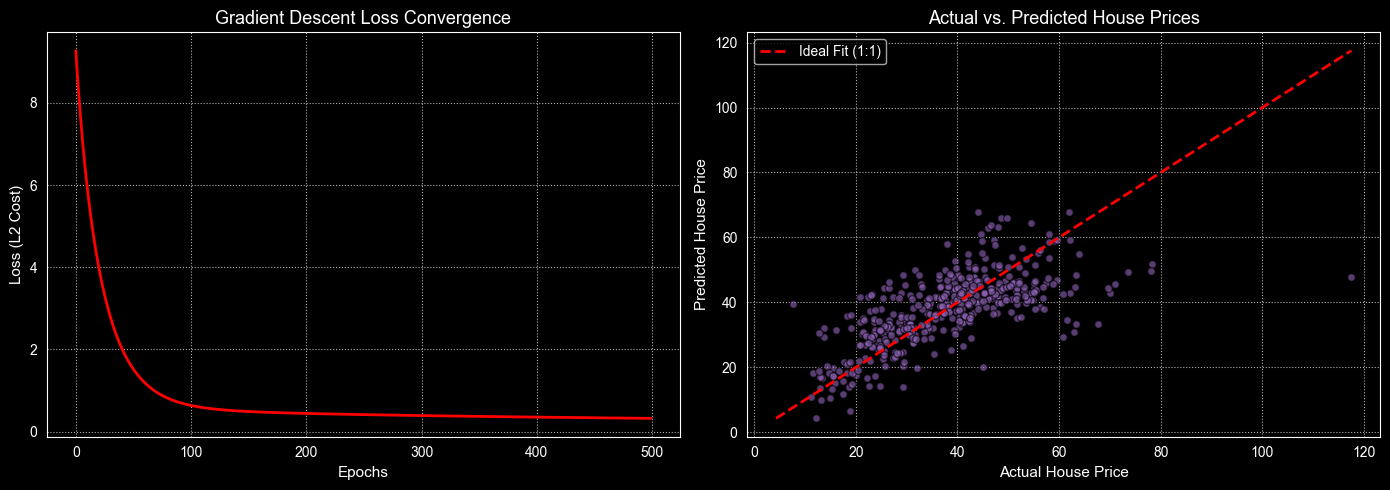

In [86]:
import matplotlib.pyplot as plt

# Create a figure with two subplots for evaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Training Loss vs. Epochs
axes[0].plot(ridge.losses, color='red', linewidth=2)
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Loss (L2 Cost)', fontsize=11)
axes[0].set_title('Gradient Descent Loss Convergence', fontsize=13)
axes[0].grid(True, linestyle=':', alpha=0.7)

# 2. Plot Actual vs. Predicted House Prices
Y_actual = Y.ravel()
Y_predicted = Y_pred_ridge_orignal.ravel()

axes[1].scatter(Y_actual, Y_predicted, color='#9467bd', alpha=0.6, edgecolors='k', s=30)
min_val = min(Y_actual.min(), Y_predicted.min())
max_val = max(Y_actual.max(), Y_predicted.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (1:1)')

axes[1].set_xlabel('Actual House Price', fontsize=11)
axes[1].set_ylabel('Predicted House Price', fontsize=11)
axes[1].set_title('Actual vs. Predicted House Prices', fontsize=13)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()